If I can reliably determine the mapping between FIT and JPG image data, then I can use this mapping to imputate the real brightness of the older JPGs, and possibly calibrate to correct for the data change.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from glob import glob
fit_images = sorted(glob("../../images/AllSkyImages/2026-03/*.FIT"))
jpg_images = sorted(glob("../../images/AllSkyImages/2026-03/*.JPG"))

fit_set = set(fit_images)
image_pairs = []
for jpg_filepath in jpg_images:
    fit_filepath = jpg_filepath.replace(".JPG", ".FIT")
    if fit_filepath in fit_set:
        image_pairs.append((jpg_filepath, fit_filepath))

len(image_pairs)

6863

In [3]:
image_pairs[1]

('../../images/AllSkyImages/2026-03/AllSkyImage000418696.JPG',
 '../../images/AllSkyImages/2026-03/AllSkyImage000418696.FIT')

In [4]:
from astropy.io import fits
from astropy.io.fits.hdu.image import PrimaryHDU
hdu: PrimaryHDU = fits.open(image_pairs[0][1])[0]
header = hdu.header
dict(header)

{'SIMPLE': True,
 'BITPIX': 16,
 'NAXIS': 2,
 'NAXIS1': 640,
 'NAXIS2': 480,
 'INSTRUME': 'SBIG AllSky-340',
 'DATE-OBS': '2026-03-20T23:44:20.734',
 'BSCALE': 1.0,
 'BZERO': 32768.0,
 'EXPTIME': 0.0483,
 'CBLACK': 1558,
 'CWHITE': 13762}

Detour: Let's plot some of the header values

In [5]:
def get_fit_header(filename):
    hdu: PrimaryHDU = fits.open(filename)[0]
    header = hdu.header
    return dict(header)


headers_df = pd.DataFrame.from_records(
    pd.Series(np.array(image_pairs)[:, 1]).apply(get_fit_header)
)
headers_df["DATE-OBS"] = pd.to_datetime(headers_df["DATE-OBS"])
headers_df

,SIMPLE,BITPIX,NAXIS,NAXIS1,NAXIS2,INSTRUME,DATE-OBS,BSCALE,BZERO,EXPTIME,CBLACK,CWHITE
0,True,16,2,640,480,SBIG AllSky-340,2026-03-20 23:44:20.734,1.0,32768.0,0.0483,1558,13762
1,True,16,2,640,480,SBIG AllSky-340,2026-03-20 23:45:30.059,1.0,32768.0,0.0702,1524,12874
2,True,16,2,640,480,SBIG AllSky-340,2026-03-20 23:45:49.363,1.0,32768.0,0.1091,1811,19055
3,True,16,2,640,480,SBIG AllSky-340,2026-03-20 23:46:19.437,1.0,32768.0,0.1091,1747,18371
4,True,16,2,640,480,SBIG AllSky-340,2026-03-20 23:46:49.505,1.0,32768.0,0.1091,1695,17963
...,...,...,...,...,...,...,...,...,...,...,...,...
6858,True,16,2,640,480,SBIG AllSky-340,2026-03-27 02:37:50.253,1.0,32768.0,9.3215,1793,19810
6859,True,16,2,640,480,SBIG AllSky-340,2026-03-27 02:38:49.109,1.0,32768.0,9.3215,1784,18921
6860,True,16,2,640,480,SBIG AllSky-340,2026-03-27 02:43:56.466,1.0,32768.0,9.3215,2115,27824
6861,True,16,2,640,480,SBIG AllSky-340,2026-03-27 02:45:20.036,1.0,32768.0,3.3501,1361,10656


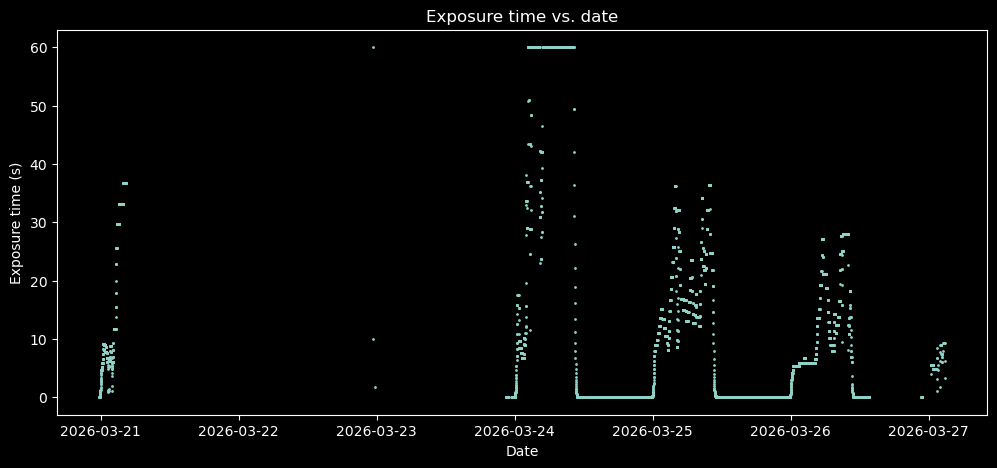

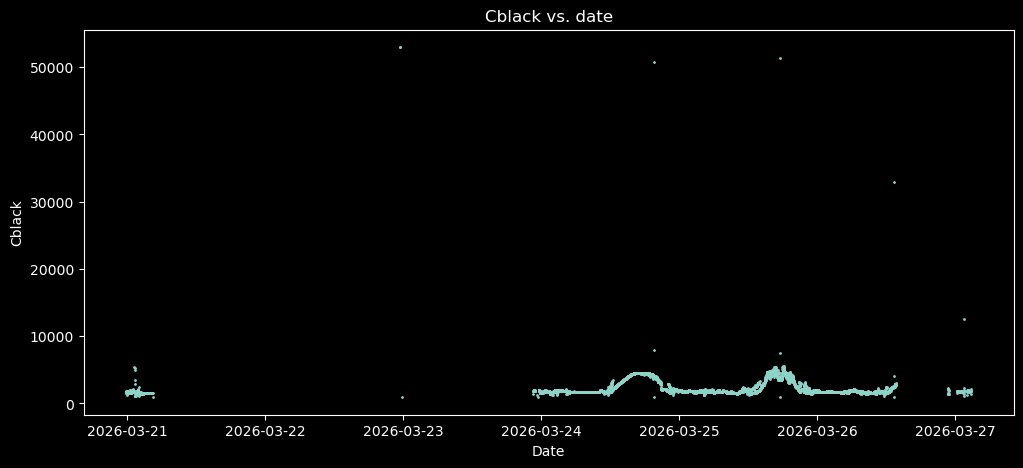

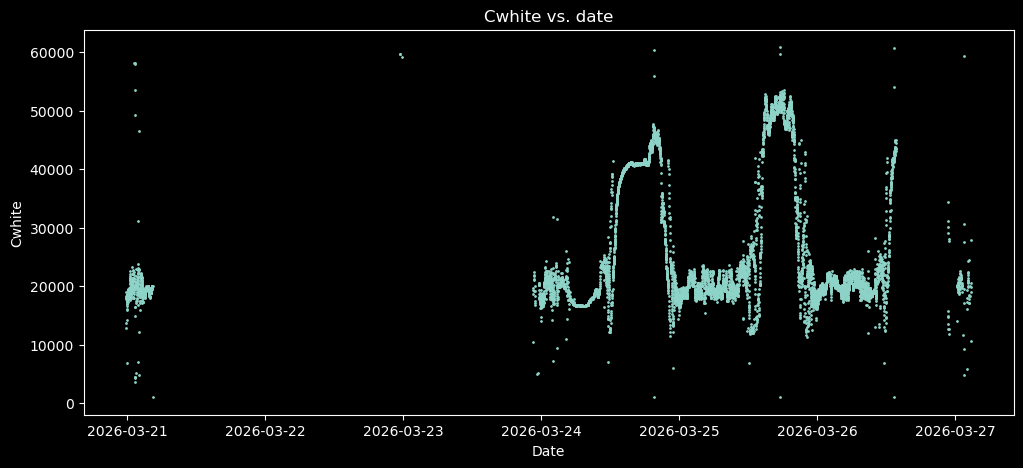

In [6]:
def plot_exposure_time(df):
    plt.figure(figsize=(12, 5))
    plt.scatter(df["DATE-OBS"], df["EXPTIME"], s=1)
    plt.xlabel("Date")
    plt.ylabel("Exposure time (s)")
    plt.title("Exposure time vs. date")

def plot_cblack(df):
    plt.figure(figsize=(12, 5))
    plt.scatter(df["DATE-OBS"], df["CBLACK"], s=1)
    plt.xlabel("Date")
    plt.ylabel("Cblack")
    plt.title("Cblack vs. date")

def plot_cwhite(df):
    plt.figure(figsize=(12, 5))
    plt.scatter(df["DATE-OBS"], df["CWHITE"], s=1)
    plt.xlabel("Date")
    plt.ylabel("Cwhite")
    plt.title("Cwhite vs. date")

plot_exposure_time(headers_df)
plot_cblack(headers_df)
plot_cwhite(headers_df)


During sunlight, the CBLACK and CWHITE values were bumped upward, adjusting the window upward so that the JPG would map values still.

CBLACK remains nearly constant outside of these periods, near zero, whereas CWHITE fluctuates from frame to frame.

This implies that a single correction factor will not be sufficient.

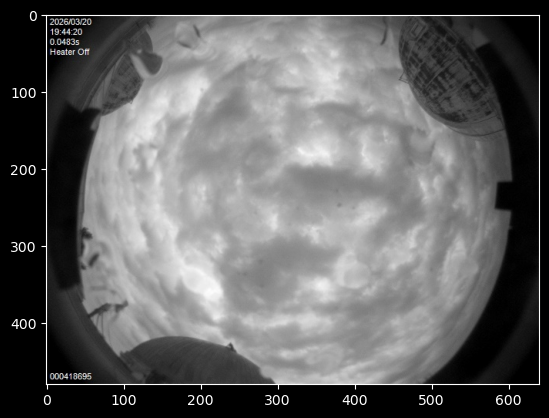

In [7]:
plt.imshow(plt.imread(image_pairs[0][0]))

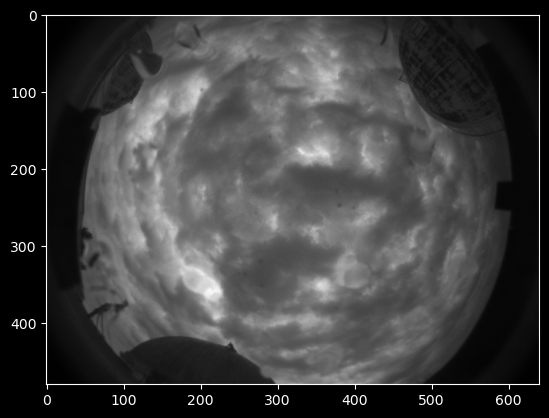

In [8]:
plt.imshow(fits.getdata(image_pairs[0][1]), cmap="gray")

In [9]:
jpg_data = plt.imread(image_pairs[0][0])
fits_data = fits.getdata(image_pairs[0][1])
jpg_data.shape, fits_data.shape

((480, 640, 3), (480, 640))

In [10]:
jpg_redchannel = jpg_data[:,:,0]
(
    (jpg_redchannel.shape, jpg_redchannel.dtype),
    (fits_data.shape, fits_data.dtype),
)

(((480, 640), dtype('uint8')), ((480, 640), dtype('uint16')))

Obviously we already knew that the FIT file has double the bit depth, but I guess it's nice to confirm it.

In [11]:
y, x = np.ogrid[:480, :640]
mask_2d = ((x - 320) ** 2 + (y - 240) ** 2 > 200 ** 2)

def mask_image(image) -> np.ma.MaskedArray:
    # np.ma.array(image, mask=mask)[40:440,120:520]

    out = image
    if image.ndim == 2:
        out = np.ma.array(image, mask=mask_2d)
    elif image.ndim == 3:
        mask_3d = np.broadcast_to(mask_2d[:, :, None], image.shape)
        out = np.ma.array(image, mask=mask_3d)
    else:
        raise ValueError(f"Unsupported image shape: {image.shape}")
    return out[40:440,120:520]


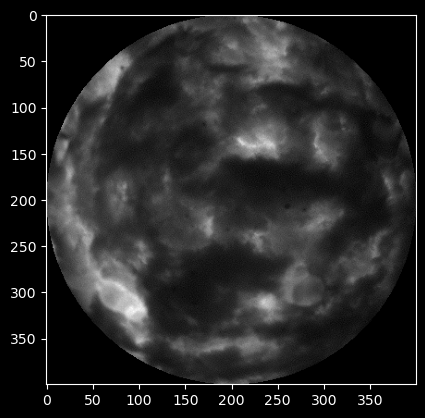

In [12]:
masked_fits = mask_image(fits_data)
masked_jpg = mask_image(jpg_redchannel)
plt.imshow((masked_fits / masked_jpg), cmap="gray")

This proves a single multiplicative factor cannot fix this. Possible we can use a linear one still.

In [13]:
header = fits.getheader(image_pairs[0][1])
header["CBLACK"], header["CWHITE"]

(1558, 13762)

In [14]:
(
    masked_jpg.argmin(),
    masked_jpg.argmax(),
    masked_fits.argmin(),
    masked_fits.argmax(),
)

(np.int64(53547), np.int64(127292), np.int64(61552), np.int64(128494))

The precise indices of the mins and maxes are not identical. Shame.

In [15]:
factors = (masked_fits / masked_jpg)

(
    factors.min(),
    factors.max(),
    factors.mean(),
    factors.std(),
)

(np.float64(52.583333333333336),
 np.float64(90.05555555555556),
 np.float64(61.0064710900282),
 np.float64(5.058225346138875))